In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150
})

PROC_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

uncertainty = pd.read_csv(RESULTS_DIR / "uncertainty_per_patient.csv")
clinical = pd.read_csv(PROC_DIR / "clinical_final.csv", index_col='cbio_patient_id')
cp_results = pd.read_csv(RESULTS_DIR / "conformal_results.csv")
baseline = pd.read_csv(RESULTS_DIR / "baseline_results.csv")
drug = pd.read_csv(PROC_DIR / "drug_final.csv")

merged = uncertainty.merge(clinical[['ELN2017_clean', 'FLT3_ITD', 'NPM1']],
                           left_on='cbio_patient_id', right_index=True, how='left')

print("all data loaded.")
print("merged records:", len(merged))

all data loaded.
merged records: 7000


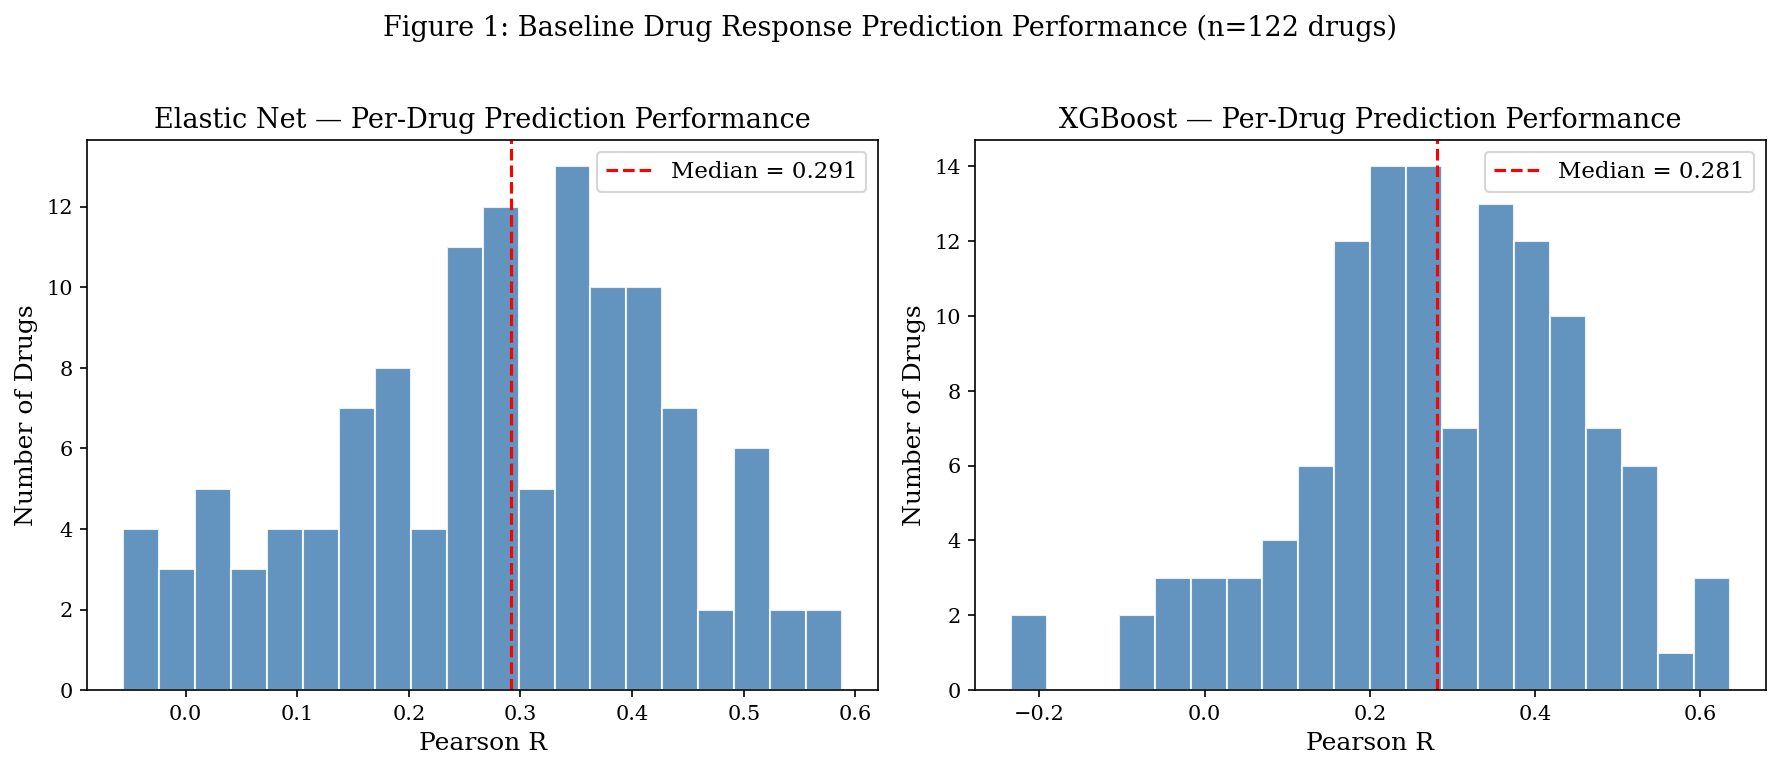

Saved fig1_baseline_performance.png


In [2]:
# figure 1: Baseline model performance across drugs

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes, ['pearson_en', 'pearson_xgb'], ['Elastic Net', 'XGBoost']):
    ax.hist(baseline[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(baseline[col].median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median = {baseline[col].median():.3f}')
    ax.set_xlabel("Pearson R")
    ax.set_ylabel("Number of Drugs")
    ax.set_title(f"{label} — Per-Drug Prediction Performance")
    ax.legend()

plt.suptitle("Figure 1: Baseline Drug Response Prediction Performance (n=122 drugs)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_baseline_performance.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig1_baseline_performance.png")

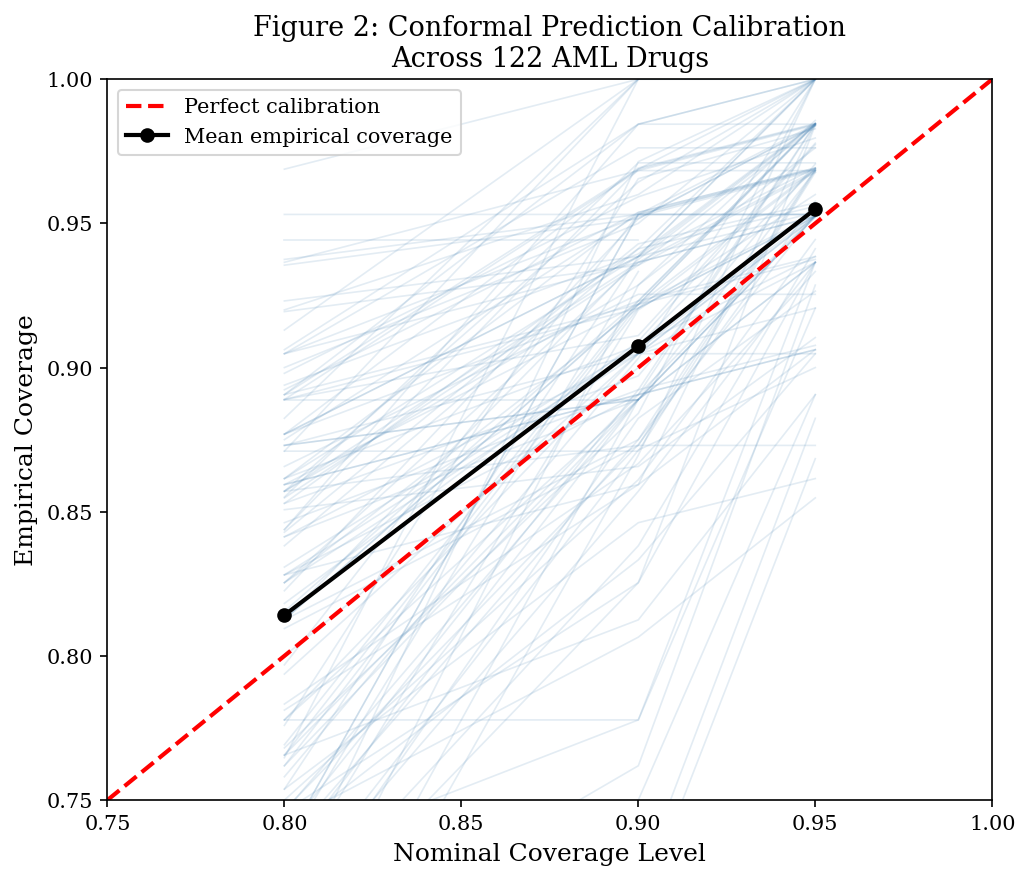

Saved fig2_calibration_curves.png


In [3]:
# figure 2: Calibration curves

fig, ax = plt.subplots(figsize=(7, 6))

nominal = [0.80, 0.90, 0.95]
for _, row in cp_results.iterrows():
    empirical = []
    nom = []
    for cl in nominal:
        val = row[f'coverage_{int(cl*100)}']
        if not np.isnan(val):
            empirical.append(val)
            nom.append(cl)
    ax.plot(nom, empirical, color='steelblue', alpha=0.15, linewidth=0.8)

ax.plot([0.75, 1.0], [0.75, 1.0], 'r--', linewidth=2, label='Perfect calibration')

mean_empirical = [cp_results[f'coverage_{int(cl*100)}'].mean() for cl in nominal]
ax.plot(nominal, mean_empirical, 'ko-', linewidth=2, markersize=6, label='Mean empirical coverage')

ax.set_xlabel("Nominal Coverage Level")
ax.set_ylabel("Empirical Coverage")
ax.set_title("Figure 2: Conformal Prediction Calibration\nAcross 122 AML Drugs")
ax.legend(fontsize=10)
ax.set_xlim(0.75, 1.0)
ax.set_ylim(0.75, 1.0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_calibration_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig2_calibration_curves.png")

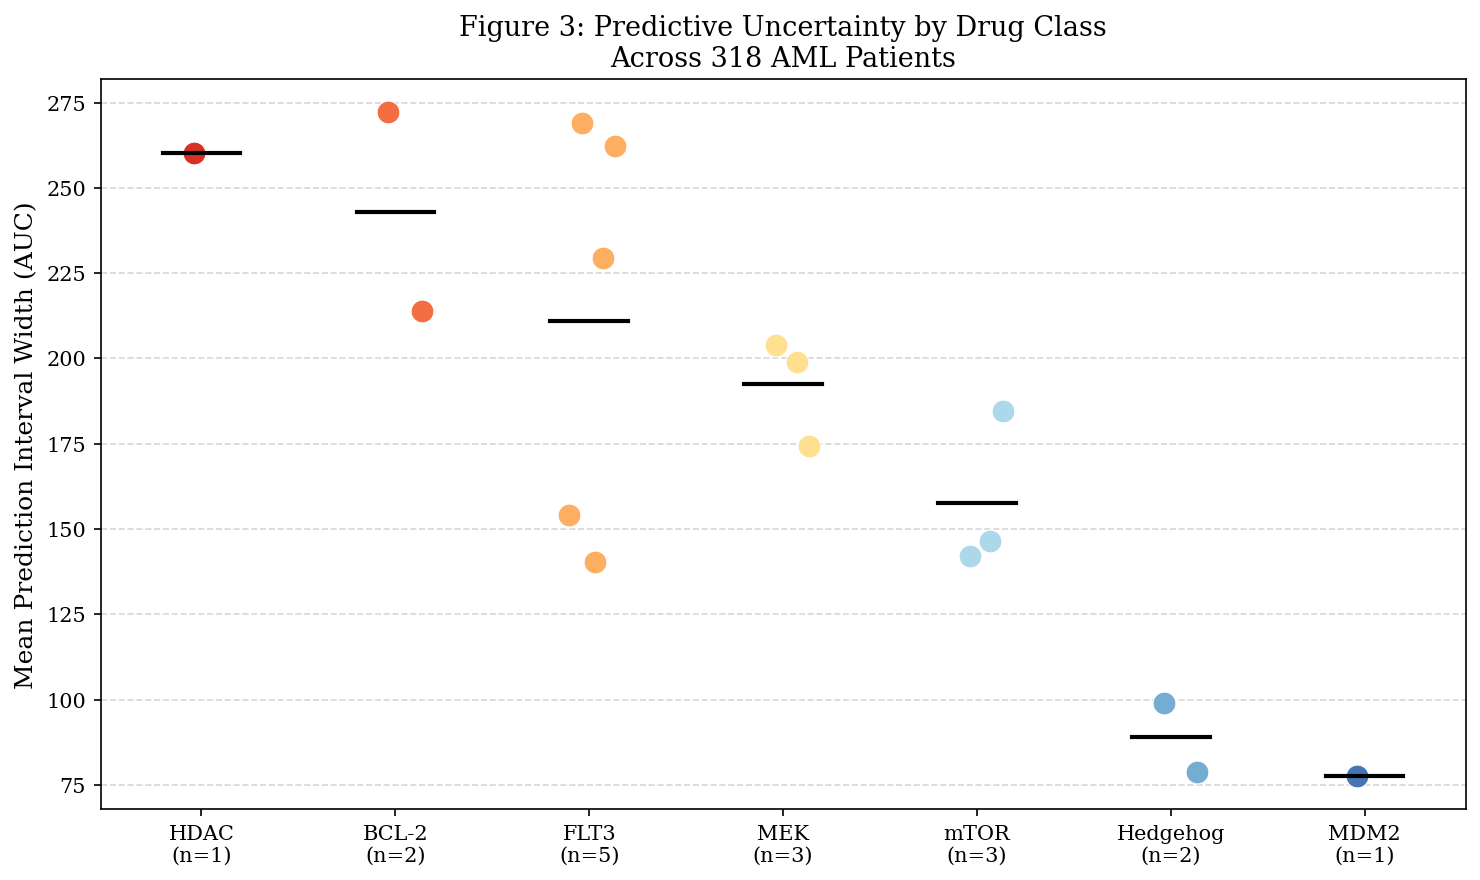

Saved.


In [9]:
# figure 3: Drug-class uncertainty

import matplotlib.pyplot as plt
import numpy as np


drug_families = drug_families_corrected

class_data = {}
for cls, drugs in drug_families.items():
    widths = [drug_width[d] for d in drugs if d in drug_width.index]
    if widths:
        class_data[cls] = widths

labels = sorted(class_data.keys(), key=lambda x: np.mean(class_data[x]), reverse=True)
colors = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#abd9e9', '#74add1', '#4575b4']

fig, ax = plt.subplots(figsize=(10, 6))

for i, (cls, color) in enumerate(zip(labels, colors)):
    widths = class_data[cls]
    n = len(widths)
    jitter = np.random.RandomState(42).uniform(-0.15, 0.15, n)
    ax.scatter([i + j for j in jitter], widths, color=color, s=120,
               zorder=3, edgecolors='white', linewidths=0.5)
    ax.plot([i - 0.2, i + 0.2], [np.mean(widths)] * 2,
            color='black', linewidth=2, zorder=4)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f"{l}\n(n={len(class_data[l])})" for l in labels], fontsize=10)
ax.set_ylabel("Mean Prediction Interval Width (AUC)", fontsize=12)
ax.set_title("Figure 3: Predictive Uncertainty by Drug Class\nAcross 318 AML Patients", fontsize=13)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures/fig3_uncertainty_by_drug_class.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")

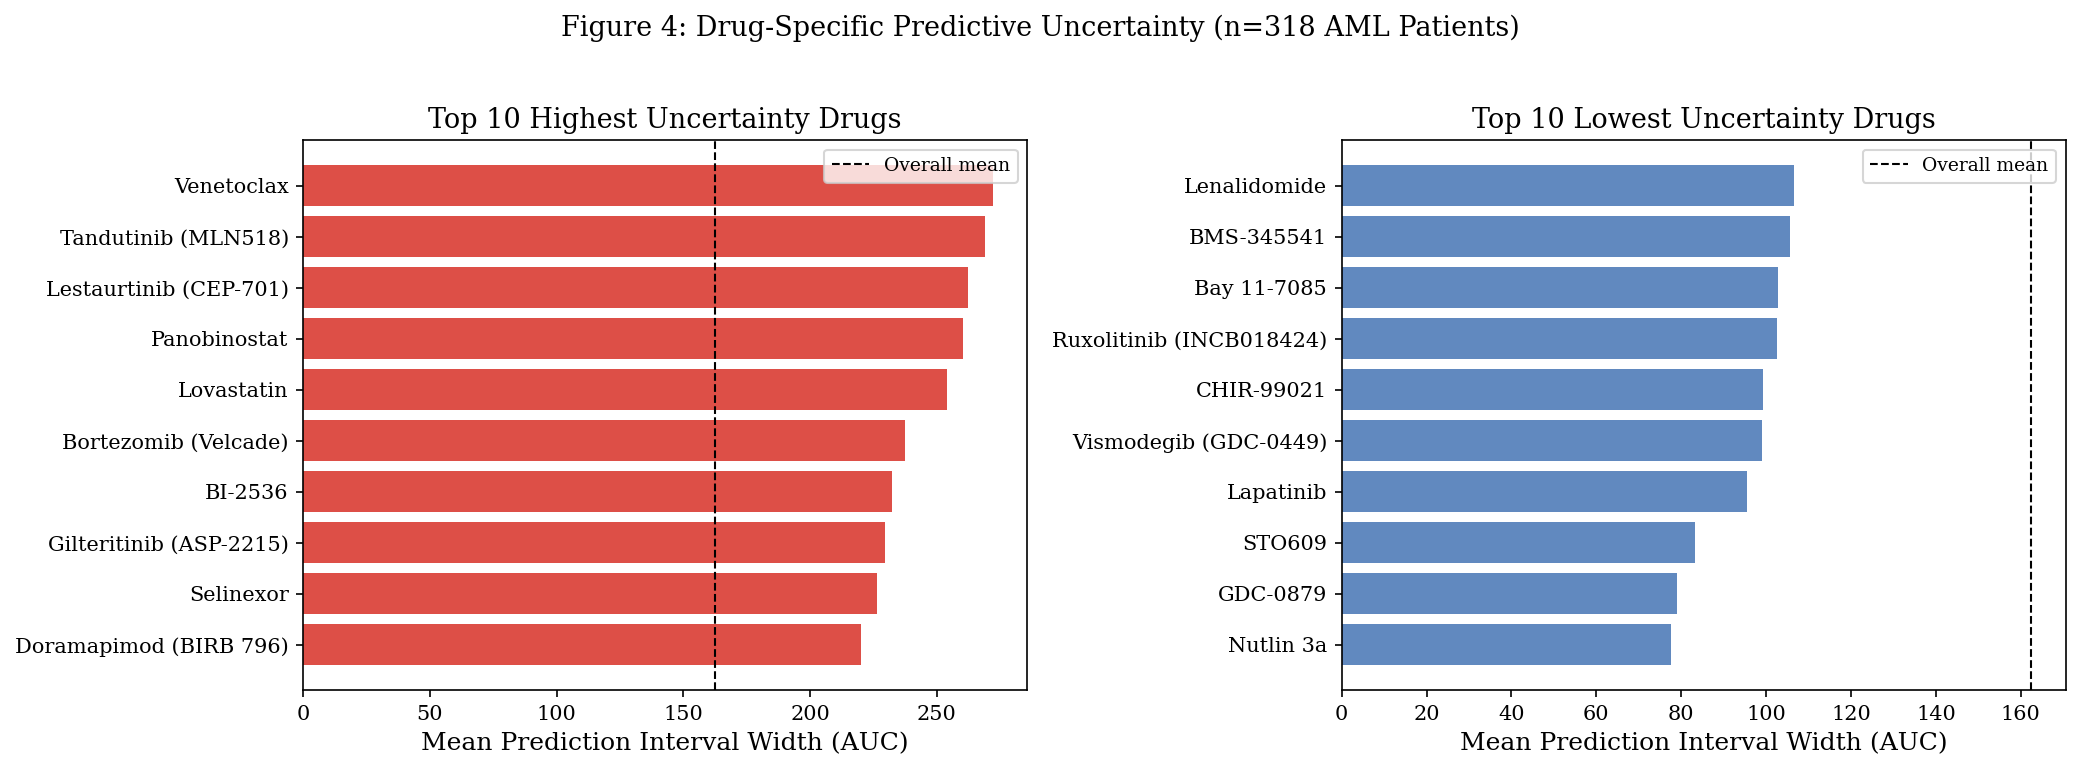

Saved fig4_top_bottom_drugs.png


In [5]:
# figure 4: Top & bottom 10 drugs by uncertainty

drug_width = merged.groupby('drug')['width'].mean().sort_values(ascending=False)
top10 = drug_width.head(10)
bot10 = drug_width.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10.index[::-1], top10.values[::-1], color='#d73027', alpha=0.85)
axes[0].set_xlabel("Mean Prediction Interval Width (AUC)")
axes[0].set_title("Top 10 Highest Uncertainty Drugs")
axes[0].axvline(drug_width.mean(), color='black', linestyle='--', linewidth=1, label='Overall mean')
axes[0].legend(fontsize=9)

axes[1].barh(bot10.index[::-1], bot10.values[::-1], color='#4575b4', alpha=0.85)
axes[1].set_xlabel("Mean Prediction Interval Width (AUC)")
axes[1].set_title("Top 10 Lowest Uncertainty Drugs")
axes[1].axvline(drug_width.mean(), color='black', linestyle='--', linewidth=1, label='Overall mean')
axes[1].legend(fontsize=9)

plt.suptitle("Figure 4: Drug-Specific Predictive Uncertainty (n=318 AML Patients)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_top_bottom_drugs.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig4_top_bottom_drugs.png")

Heatmap shape: (30, 136)
Missing values: 3069


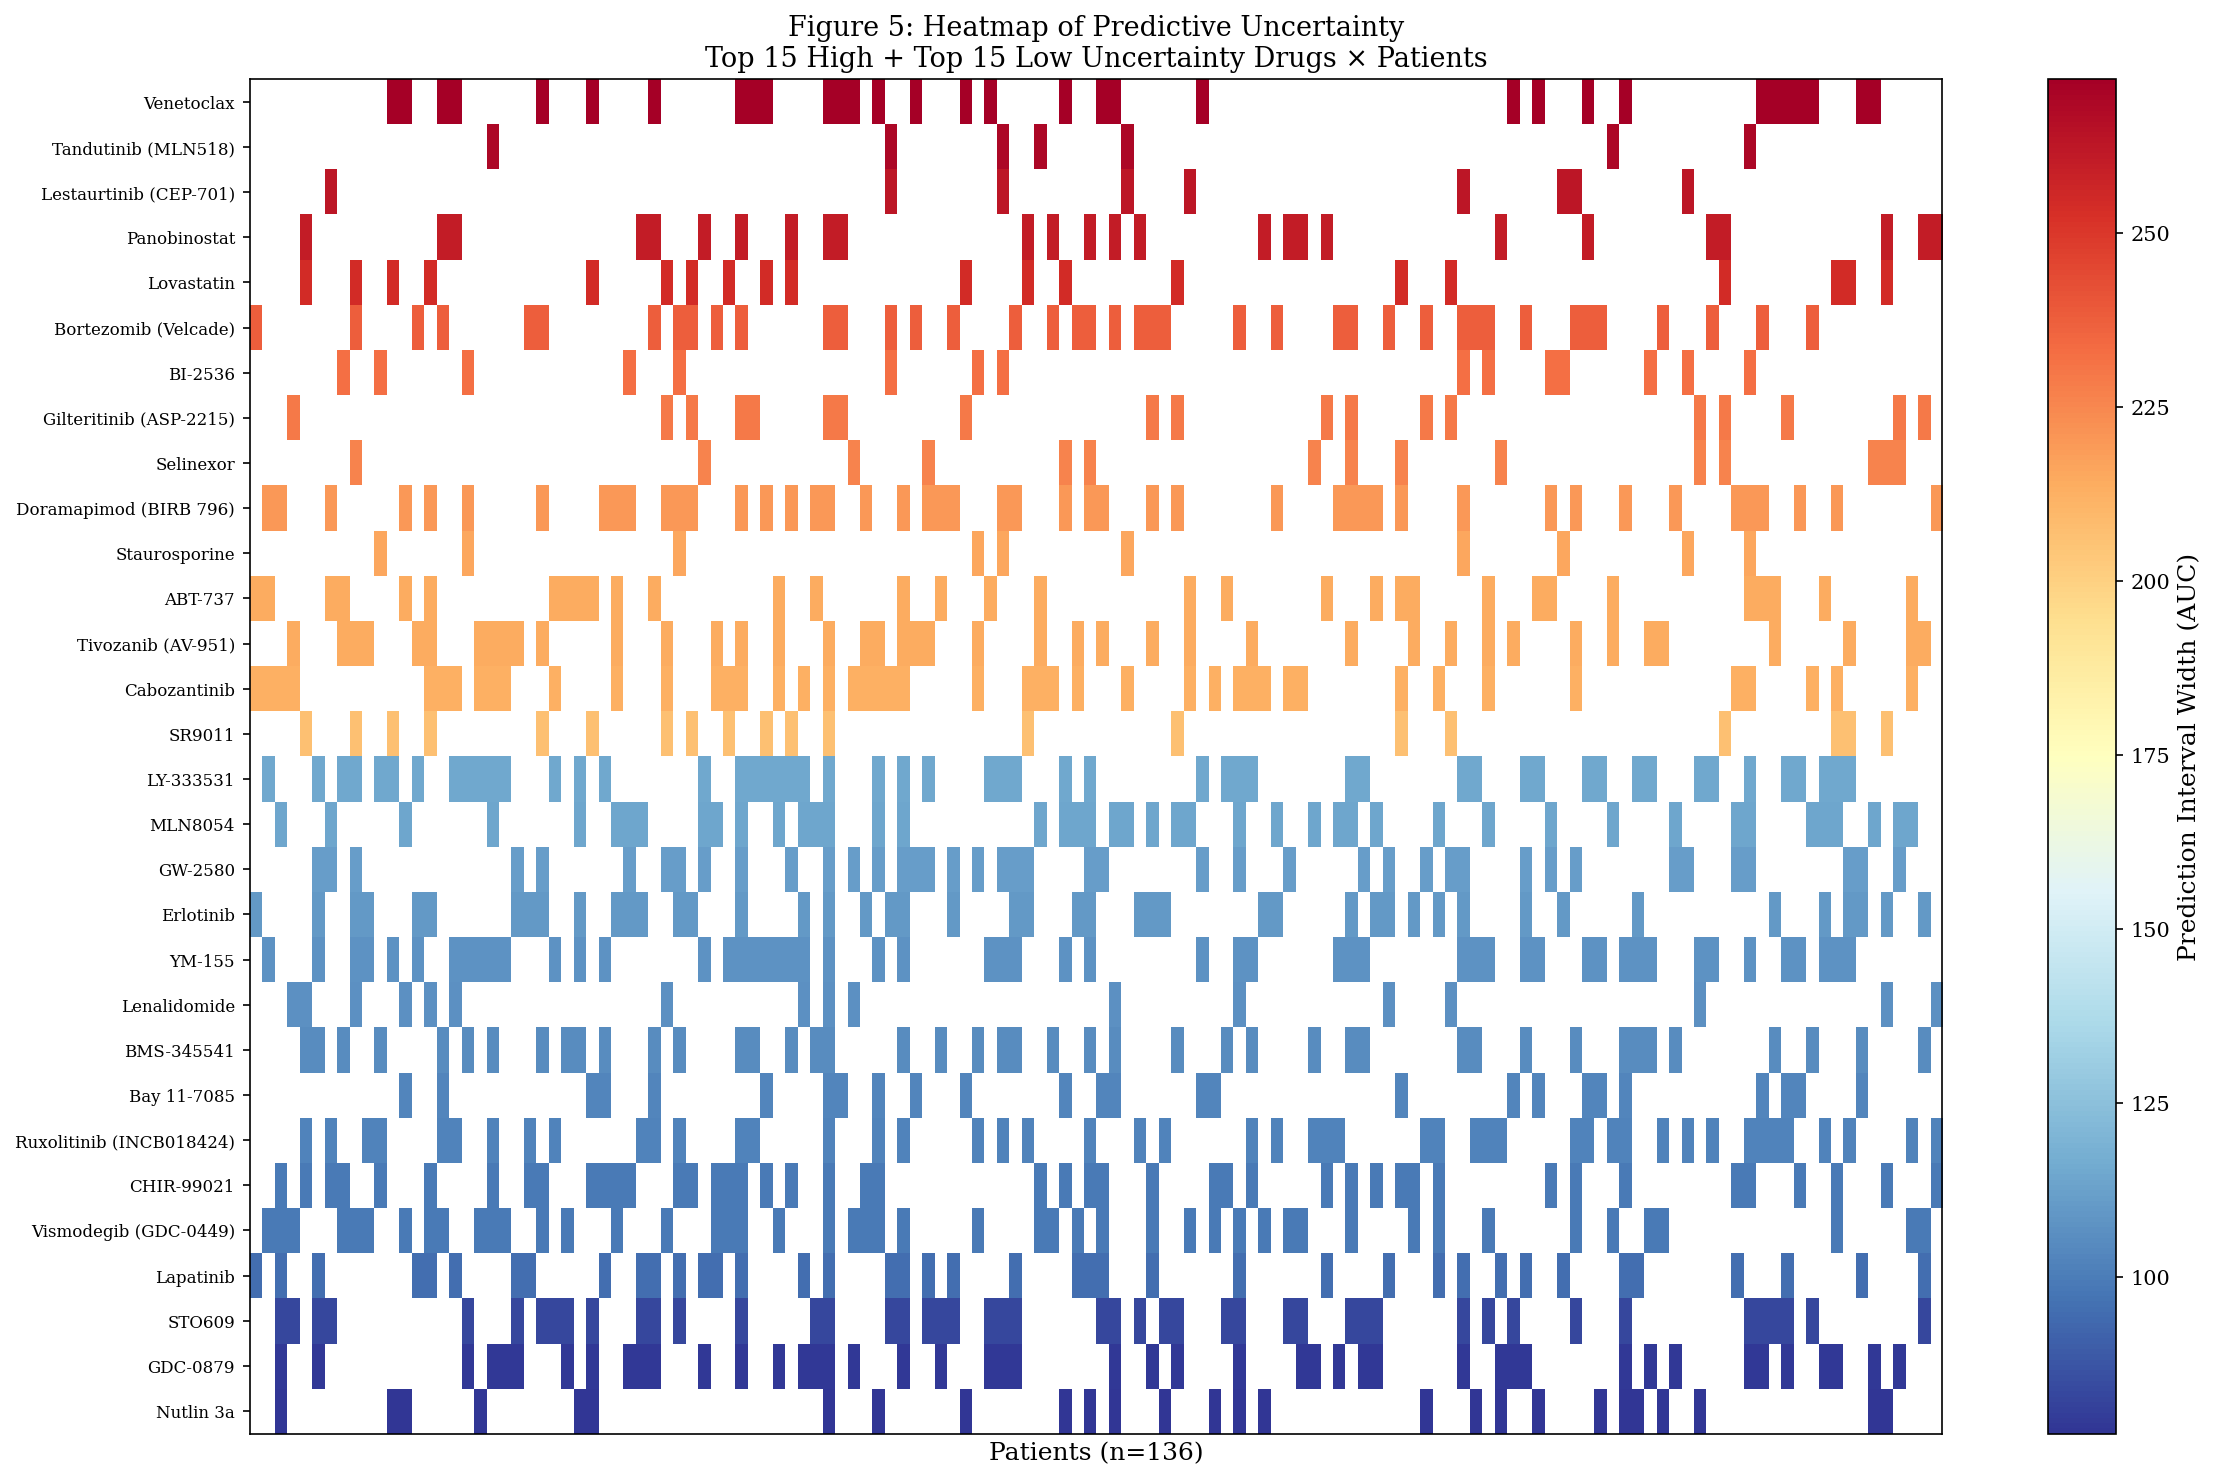

Saved.


In [7]:
# figure 5: Patient-level uncertainty heatmap(dugs x patients for top variable drugs)

top_drugs = drug_width.head(15).index.tolist()
bot_drugs = drug_width.tail(15).index.tolist()
selected_drugs = top_drugs + bot_drugs

pivot = uncertainty[uncertainty['drug'].isin(selected_drugs)].pivot_table(
    index='drug', columns='cbio_patient_id', values='width', aggfunc='mean')

pivot = pivot.loc[[d for d in selected_drugs if d in pivot.index]]
pivot = pivot.dropna(axis=1, thresh=5)

print(f"Heatmap shape: {pivot.shape}")
print(f"Missing values: {pivot.isnull().sum().sum()}")

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlBu_r', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Prediction Interval Width (AUC)')

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks([])
ax.set_xlabel(f"Patients (n={pivot.shape[1]})")
ax.set_title("Figure 5: Heatmap of Predictive Uncertainty\nTop 15 High + Top 15 Low Uncertainty Drugs × Patients")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_uncertainty_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved.")